In [1]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# get the csvs to df
train_txn = pd.read_csv('rawdata/train_transaction.csv')
train_id = pd.read_csv('rawdata/train_identity.csv')
train_combined = train_txn.merge(train_id, on='TransactionID', how='left')

test_txn = pd.read_csv('rawdata/test_transaction.csv')
test_id = pd.read_csv('rawdata/test_identity.csv')
test_combined = test_txn.merge(test_id, on='TransactionID', how='left')


# EDA

In [4]:
print('Train:')
print(train_combined.shape)
print('--------------------------------')
print(train_combined.dtypes)
print('--------------------------------')
print(train_combined.dtypes.value_counts())
print('--------------------------------')
print(train_combined.memory_usage(deep=True).sum() / 1e9, "GB")

Train:
(590540, 434)
--------------------------------
TransactionID       int64
isFraud             int64
TransactionDT       int64
TransactionAmt    float64
ProductCD             str
                   ...   
id_36                 str
id_37                 str
id_38                 str
DeviceType            str
DeviceInfo            str
Length: 434, dtype: object
--------------------------------
float64    399
str         31
int64        4
Name: count, dtype: int64
--------------------------------
2.636093316 GB


In [5]:
print('Test:')
print(test_combined.shape)
print('--------------------------------')
print(test_combined.dtypes)
print('--------------------------------')
print(test_combined.dtypes.value_counts())
print('--------------------------------')
print(test_combined.memory_usage(deep=True).sum() / 1e9, "GB")

Test:
(506691, 433)
--------------------------------
TransactionID       int64
TransactionDT       int64
TransactionAmt    float64
ProductCD             str
card1               int64
                   ...   
id-36                 str
id-37                 str
id-38                 str
DeviceType            str
DeviceInfo            str
Length: 433, dtype: object
--------------------------------
float64    399
str         31
int64        3
Name: count, dtype: int64
--------------------------------
2.269222644 GB


In [6]:
train_combined.head(5)

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


In [7]:
train_combined.describe()

,TransactionID,isFraud,TransactionDT,TransactionAmt,card1,card2,card3,card5,addr1,addr2,...,id_17,id_18,id_19,id_20,id_21,id_22,id_24,id_25,id_26,id_32
count,5.905400e+05,590540.000000,5.905400e+05,590540.000000,590540.000000,581607.000000,588975.000000,586281.000000,524834.000000,524834.000000,...,139369.000000,45113.000000,139318.000000,139261.000000,5159.000000,5169.000000,4747.000000,5132.000000,5163.000000,77586.000000
mean,3.282270e+06,0.034990,7.372311e+06,135.027176,9898.734658,362.555488,153.194925,199.278897,290.733794,86.800630,...,189.451377,14.237337,353.128174,403.882666,368.269820,16.002708,12.800927,329.608924,149.070308,26.508597
std,1.704744e+05,0.183755,4.617224e+06,239.162522,4901.170153,157.793246,11.336444,41.244453,101.741072,2.690623,...,30.375360,1.561302,141.095343,152.160327,198.847038,6.897665,2.372447,97.461089,32.101995,3.737502
min,2.987000e+06,0.000000,8.640000e+04,0.251000,1000.000000,100.000000,100.000000,100.000000,100.000000,10.000000,...,100.000000,10.000000,100.000000,100.000000,100.000000,10.000000,11.000000,100.000000,100.000000,0.000000
25%,3.134635e+06,0.000000,3.027058e+06,43.321000,6019.000000,214.000000,150.000000,166.000000,204.000000,87.000000,...,166.000000,13.000000,266.000000,256.000000,252.000000,14.000000,11.000000,321.000000,119.000000,24.000000
50%,3.282270e+06,0.000000,7.306528e+06,68.769000,9678.000000,361.000000,150.000000,226.000000,299.000000,87.000000,...,166.000000,15.000000,341.000000,472.000000,252.000000,14.000000,11.000000,321.000000,149.000000,24.000000
75%,3.429904e+06,0.000000,1.124662e+07,125.000000,14184.000000,512.000000,150.000000,226.000000,330.000000,87.000000,...,225.000000,15.000000,427.000000,533.000000,486.500000,14.000000,15.000000,371.000000,169.000000,32.000000
max,3.577539e+06,1.000000,1.581113e+07,31937.391000,18396.000000,600.000000,231.000000,237.000000,540.000000,102.000000,...,229.000000,29.000000,671.000000,661.000000,854.000000,44.000000,26.000000,548.000000,216.000000,32.000000


In [12]:
test_combined.head(5)

,TransactionID,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,...,id-31,id-32,id-33,id-34,id-35,id-36,id-37,id-38,DeviceType,DeviceInfo
0,3663549,18403224,31.95,W,10409,111.0,150.0,visa,226.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3663550,18403263,49.00,W,4272,111.0,150.0,visa,226.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3663551,18403310,171.00,W,4476,574.0,150.0,visa,226.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3663552,18403310,284.95,W,10989,360.0,150.0,visa,166.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,3663553,18403317,67.95,W,18018,452.0,150.0,mastercard,117.0,debit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
test_combined.describe()

,TransactionID,TransactionDT,TransactionAmt,card1,card2,card3,card5,addr1,addr2,dist1,...,id-17,id-18,id-19,id-20,id-21,id-22,id-24,id-25,id-26,id-32
count,5.066910e+05,5.066910e+05,506691.000000,506691.000000,498037.000000,503689.000000,502144.000000,441082.000000,441082.000000,215474.000000,...,135966.000000,50875.000000,135906.000000,135633.000000,5059.000000,5062.000000,4740.000000,5039.000000,5047.000000,70671.000000
mean,3.916894e+06,2.692994e+07,134.725568,9957.222175,363.735379,153.543409,200.162975,291.846514,86.723412,87.065270,...,191.070341,14.795735,350.122982,408.886230,507.727021,15.336823,13.166667,332.043064,152.752923,26.217939
std,1.462692e+05,4.756507e+06,245.779822,4884.960969,158.688653,12.443013,40.562461,102.062730,2.987328,314.131694,...,30.749535,2.318496,139.140824,158.971756,227.371061,5.618032,3.222440,86.356683,31.916995,3.601046
min,3.663549e+06,1.840322e+07,0.018000,1001.000000,100.000000,100.000000,100.000000,100.000000,10.000000,0.000000,...,100.000000,11.000000,100.000000,100.000000,100.000000,11.000000,10.000000,100.000000,100.000000,8.000000
25%,3.790222e+06,2.277154e+07,40.000000,6019.000000,207.000000,150.000000,166.000000,204.000000,87.000000,3.000000,...,166.000000,13.000000,266.000000,256.000000,252.000000,14.000000,11.000000,321.000000,137.000000,24.000000
50%,3.916894e+06,2.720466e+07,67.950000,9803.000000,369.000000,150.000000,226.000000,299.000000,87.000000,8.000000,...,166.000000,15.000000,321.000000,484.000000,576.000000,14.000000,11.000000,321.000000,147.000000,24.000000
75%,4.043566e+06,3.134856e+07,125.000000,14276.000000,512.000000,150.000000,226.000000,330.000000,87.000000,20.000000,...,225.000000,15.000000,427.000000,549.000000,711.000000,14.000000,15.000000,355.000000,182.000000,32.000000
max,4.170239e+06,3.421434e+07,10270.000000,18397.000000,600.000000,232.000000,237.000000,540.000000,102.000000,8081.000000,...,228.000000,29.000000,670.000000,660.000000,854.000000,44.000000,26.000000,549.000000,216.000000,48.000000


In [9]:
train_combined['isFraud'].value_counts(normalize=True)

isFraud
0    0.96501
1    0.03499
Name: proportion, dtype: float64

In [4]:
# combine datasets to find overall min/max TransactionDT for normalization
all_transaction_dts = pd.concat([train_df['TransactionDT'], test_df['TransactionDT']])
min_dt = all_transaction_dts.min()
max_dt = all_transaction_dts.max()
print(f"min_dt: {min_dt}, max_dt: {max_dt}")

min_dt: 86400, max_dt: 34214345


<class 'pandas.Series'>
434


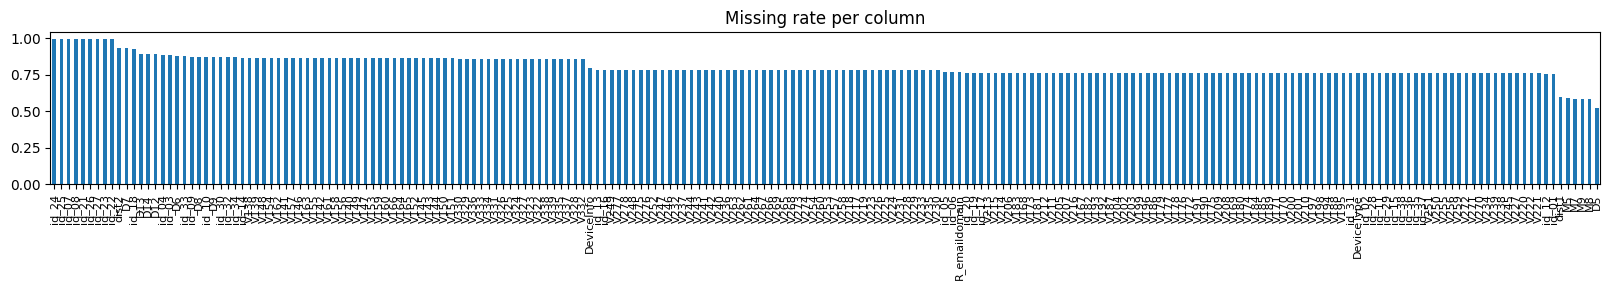

In [ ]:
# any cells with missing value
missing = train_combined.isnull().mean().sort_values(ascending=False)
print(type(missing))
print(missing.size) # pandas Series object has no len(s) function
ax = missing[missing > 0.5].plot(kind='bar', figsize=(20,4), title='Missing rate per column')
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=8)
plt.subplots_adjust(bottom=0.5)
#plt.tight_layout()
plt.show()
# there are lots of missing values
# any features that has more than half of its entry missing => discard them?

In [41]:
print(train_combined.columns.tolist())

['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt', 'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6', 'addr1', 'addr2', 'dist1', 'dist2', 'P_emaildomain', 'R_emaildomain', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8', 'D9', 'D10', 'D11', 'D12', 'D13', 'D14', 'D15', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'V29', 'V30', 'V31', 'V32', 'V33', 'V34', 'V35', 'V36', 'V37', 'V38', 'V39', 'V40', 'V41', 'V42', 'V43', 'V44', 'V45', 'V46', 'V47', 'V48', 'V49', 'V50', 'V51', 'V52', 'V53', 'V54', 'V55', 'V56', 'V57', 'V58', 'V59', 'V60', 'V61', 'V62', 'V63', 'V64', 'V65', 'V66', 'V67', 'V68', 'V69', 'V70', 'V71', 'V72', 'V73', 'V74', 'V75', 'V76', 'V77', 'V78', 'V79', 'V80', 'V81', 'V

182


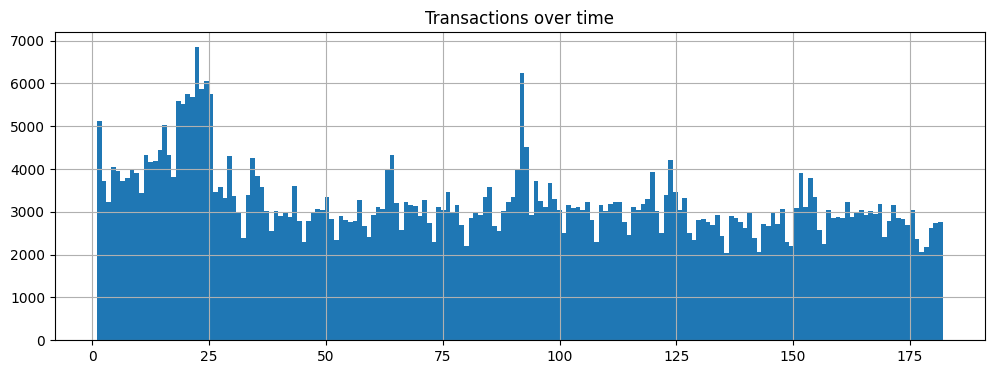

In [52]:
# time distribution
train_combined['TransactionDay'] = train_combined['TransactionDT'] // 86400 # 86400 seconds per day
train_combined['TransactionDay'].hist(bins=182, figsize=(12,4))
train_combined = train_combined.copy()
plt.title('Transactions over time')
# counts how many days are there in the train dataset / how long is the dataset collected
print(train_combined['TransactionDay'].nunique())

Text(0.5, 1.0, 'Fraud rate over time')

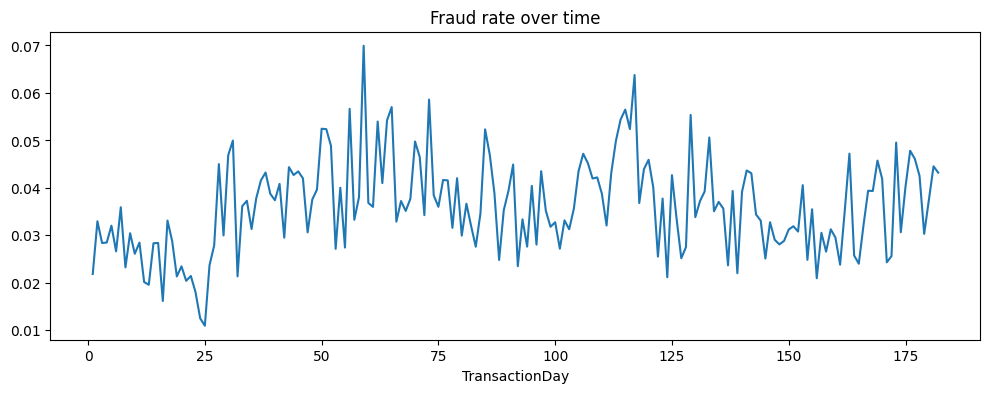

In [53]:
# fraud rate over time
train_combined.groupby('TransactionDay')['isFraud'].mean().plot(figsize=(12,4))
plt.title('Fraud rate over time')

<Axes: >

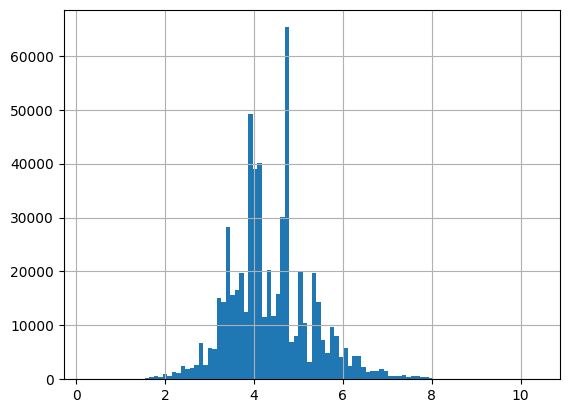

In [54]:
# transaction amount distribution
np.log1p(train_combined['TransactionAmt']).hist(bins=100)

In [55]:
# card column families
for col in ['card1','card2','card3','card4','card5','card6']:
    print(col, train_combined[col].nunique(), 'unique values')

card1 13553 unique values
card2 500 unique values
card3 114 unique values
card4 4 unique values
card5 119 unique values
card6 4 unique values


In [57]:
# looking for missing data,
# outliers/range sanity
# scale differences
# skew hints
train_combined[['D1','D2','D3','D4','D10','D15']].describe()

,D1,D2,D3,D4,D10,D15
count,589271.000000,309743.000000,327662.000000,421618.000000,514518.000000,501427.000000
mean,94.347568,169.563231,28.343348,140.002441,123.982137,163.744579
std,157.660387,177.315865,62.384721,191.096774,182.615225,202.726660
min,0.000000,0.000000,0.000000,-122.000000,0.000000,-83.000000
25%,0.000000,26.000000,1.000000,0.000000,0.000000,0.000000
50%,3.000000,97.000000,8.000000,26.000000,15.000000,52.000000
75%,122.000000,276.000000,27.000000,253.000000,197.000000,314.000000
max,640.000000,640.000000,819.000000,869.000000,876.000000,879.000000
